# Polish Demographic Structure by Voivodeship, 1995–2024

This project analyses how the age structure of Polish voivodeships changed between 1995 and 2024. The main question is whether some regions appear noticeably “older” or “younger” than others.

The data comes from the Polish Central Statistical Office database, Bank Danych Lokalnych / GUS. The dataset contains population counts by region, age group, sex, year, and unit. In this analysis I use total population for both sexes combined (`ogółem`) and compare the 16 voivodeships, excluding the national total `POLSKA`.

Because voivodeships have very different population sizes, the analysis uses age-group shares of each region's total population rather than raw population counts.

Source: https://bdl.stat.gov.pl/bdl/dane/podgrup/tablica

## 1. Loading and cleaning the data

The original dataset is in a wide format: each region is one row, while columns contain combinations of age group, sex, year, and unit. To make the data easier to analyse, I reshape it into long format, where every row represents one observation for a given region, age group, sex, and year.

In [3]:
ludn = read.csv2("Data/LUDN_2137.csv")
ludn

Kod,Nazwa,ogółem.ogółem.1995..osoba.,ogółem.ogółem.1996..osoba.,ogółem.ogółem.1997..osoba.,ogółem.ogółem.1998..osoba.,ogółem.ogółem.1999..osoba.,ogółem.ogółem.2000..osoba.,ogółem.ogółem.2001..osoba.,ogółem.ogółem.2002..osoba.,⋯,X0.14.kobiety.2017..osoba.,X0.14.kobiety.2018..osoba.,X0.14.kobiety.2019..osoba.,X0.14.kobiety.2020..osoba.,X0.14.kobiety.2021..osoba.,X0.14.kobiety.2022..osoba.,X0.14.kobiety.2023..osoba.,X0.14.kobiety.2024..osoba.,X0.14.kobiety.2025..osoba.,X
<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<lgl>,<lgl>
0,POLSKA,38609399,38639341,38659979,38666983,38263303,38253955,38242197,38218531,⋯,2835028,2854253,2865308,2891597,2873363,2830372,2757563,2671473,NA,NA
200000,DOLNOŚLĄSKIE,2988278,2986884,2985381,2982128,2917139,2912195,2909622,2904694,⋯,202480,204743,206030,207965,207442,204937,199848,193453,NA,NA
400000,KUJAWSKO-POMORSKIE,2092977,2095819,2098018,2100106,2068864,2067817,2069747,2069166,⋯,153046,153018,152614,153250,151420,148209,143399,137605,NA,NA
600000,LUBELSKIE,2244628,2244212,2241952,2239500,2209083,2206200,2201720,2196992,⋯,152895,152446,151730,152834,150681,147295,142526,137160,NA,NA
800000,LUBUSKIE,1014591,1017596,1020345,1022521,1007967,1008472,1008983,1008196,⋯,75539,75652,75505,75157,73922,72046,69597,66944,NA,NA
1000000,ŁÓDZKIE,2687761,2680350,2672823,2663608,2637438,2627824,2617318,2607380,⋯,170877,171649,171446,171026,169389,166685,162039,156699,NA,NA
1200000,MAŁOPOLSKIE,3190186,3197064,3206630,3215885,3217865,3229139,3236268,3237217,⋯,262009,264624,267467,273493,273611,271428,266498,260506,NA,NA
1400000,MAZOWIECKIE,5060091,5061049,5064950,5066598,5112652,5115010,5121681,5128623,⋯,422251,428593,433585,442379,442433,439011,431073,420645,NA,NA
1600000,OPOLSKIE,1093172,1092524,1091077,1089586,1074205,1070598,1066438,1061009,⋯,63737,64051,64327,65028,64580,63657,62184,60133,NA,NA


In [4]:
install.packages("tidyverse")
install.packages("janitor")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’




In [5]:
library(tidyverse)
library(janitor)

ludn_raw <- read.csv2(
  "Data/LUDN_2137.csv",
  check.names = FALSE,
  stringsAsFactors = FALSE
)

ludn_clean <- ludn_raw %>%
  select(where(~ !all(is.na(.)))) %>%
  remove_empty("cols")

ludn_long <- ludn_clean %>%
  pivot_longer(
    cols = -c(Kod, Nazwa),
    names_to = "variable",
    values_to = "population"
  )

ludn_long

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




Kod,Nazwa,variable,population
<int>,<chr>,<chr>,<int>
0,POLSKA,ogółem;ogółem;1995;[osoba],38609399
0,POLSKA,ogółem;ogółem;1996;[osoba],38639341
0,POLSKA,ogółem;ogółem;1997;[osoba],38659979
0,POLSKA,ogółem;ogółem;1998;[osoba],38666983
0,POLSKA,ogółem;ogółem;1999;[osoba],38263303
0,POLSKA,ogółem;ogółem;2000;[osoba],38253955
0,POLSKA,ogółem;ogółem;2001;[osoba],38242197
0,POLSKA,ogółem;ogółem;2002;[osoba],38218531
0,POLSKA,ogółem;ogółem;2003;[osoba],38190608


After reshaping the data, the combined column names are separated into four variables: age group, sex, year, and unit. This creates a tidy structure that can be filtered, grouped, and summarized more easily.

In [6]:
ludn_long <- ludn_long %>%
  separate(
    variable,
    into = c("age_group", "sex", "year", "unit"),
    sep = ";",
    fill = "right",
    extra = "merge"
  ) %>%
  mutate(
    year = as.integer(year),
    unit = str_remove_all(unit, "\\[|\\]"),
    population = as.numeric(population)
  )

ludn_long

Kod,Nazwa,age_group,sex,year,unit,population
<int>,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>
0,POLSKA,ogółem,ogółem,1995,osoba,38609399
0,POLSKA,ogółem,ogółem,1996,osoba,38639341
0,POLSKA,ogółem,ogółem,1997,osoba,38659979
0,POLSKA,ogółem,ogółem,1998,osoba,38666983
0,POLSKA,ogółem,ogółem,1999,osoba,38263303
0,POLSKA,ogółem,ogółem,2000,osoba,38253955
0,POLSKA,ogółem,ogółem,2001,osoba,38242197
0,POLSKA,ogółem,ogółem,2002,osoba,38218531
0,POLSKA,ogółem,ogółem,2003,osoba,38190608


The cleaned table now contains the key variables needed for analysis: region code, region name, age group, sex, year, and population. This format allows comparison across time and across voivodeships.

In [7]:
ludn_long <- ludn_long %>%
  rename(
    region_code = Kod,
    region = Nazwa
  ) %>%
  select(region_code, region, age_group, sex, year, population)

ludn_long

region_code,region,age_group,sex,year,population
<int>,<chr>,<chr>,<chr>,<int>,<dbl>
0,POLSKA,ogółem,ogółem,1995,38609399
0,POLSKA,ogółem,ogółem,1996,38639341
0,POLSKA,ogółem,ogółem,1997,38659979
0,POLSKA,ogółem,ogółem,1998,38666983
0,POLSKA,ogółem,ogółem,1999,38263303
0,POLSKA,ogółem,ogółem,2000,38253955
0,POLSKA,ogółem,ogółem,2001,38242197
0,POLSKA,ogółem,ogółem,2002,38218531
0,POLSKA,ogółem,ogółem,2003,38190608


## 2. Creating broader age categories

The original data contains detailed five-year age groups, but some additional age categories overlap or are available only for part of the period. To keep the analysis consistent from 1995 to 2024, I use age groups that are available for the full time range and combine them into broader life-stage categories.

In [8]:
unique(ludn_long$age_group)

[1] "ogółem"      "0-4"         "5-9"         "10-14"       "15-19"      
 [6] "20-24"       "25-29"       "30-34"       "35-39"       "40-44"      
[11] "45-49"       "50-54"       "55-59"       "60-64"       "65-69"      
[16] "70 i więcej" "70-74"       "75-79"       "80-84"       "85 i więcej"
[21] "0-14"

This check shows which age groups are available in which years. The detailed groups above age 70 are available only from 2002 onward, while the broad `70 i więcej` category is available for the whole period. Therefore, I use `70 i więcej` to preserve comparability across all years.

In [9]:
ludn_long %>%
  filter(!is.na(population)) %>%
  group_by(age_group) %>%
  summarise(
    first_year = min(year),
    last_year = max(year),
    number_of_years = n_distinct(year)
  ) %>%
  arrange(first_year, age_group)

age_group,first_year,last_year,number_of_years
<chr>,<int>,<int>,<int>
0-4,1995,2024,30
10-14,1995,2024,30
15-19,1995,2024,30
20-24,1995,2024,30
25-29,1995,2024,30
30-34,1995,2024,30
35-39,1995,2024,30
40-44,1995,2024,30
45-49,1995,2024,30


In [10]:
ludn_long <- ludn_long %>%
  filter(
    !age_group %in% c("70-74", "75-79", "80-84", "85 i więcej", "0-14")
  )

In [11]:
ludn_long %>%
  filter(!is.na(population)) %>%
  group_by(age_group) %>%
  summarise(
    first_year = min(year),
    last_year = max(year),
    number_of_years = n_distinct(year)
  ) %>%
  arrange(first_year, age_group)

age_group,first_year,last_year,number_of_years
<chr>,<int>,<int>,<int>
0-4,1995,2024,30
10-14,1995,2024,30
15-19,1995,2024,30
20-24,1995,2024,30
25-29,1995,2024,30
30-34,1995,2024,30
35-39,1995,2024,30
40-44,1995,2024,30
45-49,1995,2024,30


In [12]:
ludn_long

region_code,region,age_group,sex,year,population
<int>,<chr>,<chr>,<chr>,<int>,<dbl>
0,POLSKA,ogółem,ogółem,1995,38609399
0,POLSKA,ogółem,ogółem,1996,38639341
0,POLSKA,ogółem,ogółem,1997,38659979
0,POLSKA,ogółem,ogółem,1998,38666983
0,POLSKA,ogółem,ogółem,1999,38263303
0,POLSKA,ogółem,ogółem,2000,38253955
0,POLSKA,ogółem,ogółem,2001,38242197
0,POLSKA,ogółem,ogółem,2002,38218531
0,POLSKA,ogółem,ogółem,2003,38190608


The detailed age groups are combined into six broader categories: early childhood, adolescence, young adulthood, middle adulthood, late adulthood, and senior population. These categories make the long-term demographic patterns easier to interpret.

In [13]:
age_grouped <- ludn_long %>%
  filter(
    region != "POLSKA",
    sex == "ogółem"
  ) %>%
  mutate(
    age_category = case_when(
      age_group %in% c("0-4", "5-9") ~ "early_childhood",
      age_group %in% c("10-14", "15-19") ~ "adolescence",
      age_group %in% c("20-24", "25-29") ~ "young_adulthood",
      age_group %in% c("30-34", "35-39", "40-44") ~ "middle_adulthood",
      age_group %in% c("45-49", "50-54", "55-59", "60-64") ~ "late_adulthood",
      age_group %in% c("65-69", "70 i więcej") ~ "senior_population",
      TRUE ~ NA_character_
    )
  ) %>%
  filter(!is.na(age_category))

In [14]:
age_grouped <- age_grouped %>%
  mutate(
    age_category_label = recode(
      age_category,
      "early_childhood" = "Early childhood (0–9)",
      "adolescence" = "Adolescence (10–19)",
      "young_adulthood" = "Young adulthood (20–29)",
      "middle_adulthood" = "Middle adulthood (30–44)",
      "late_adulthood" = "Late adulthood (45–64)",
      "senior_population" = "Senior population (65+)"
    )
  )

##

## 3. Descriptive statistical analysis

The main variable used in the analysis is the share of each age category in a voivodeship's total population. This makes regions comparable even though their absolute population sizes differ.

For each year and age category, I calculate descriptive statistics across the 16 voivodeships: mean, median, standard deviation, first and third quartile, range, and interquartile range.

In [15]:
age_grouped

region_code,region,age_group,sex,year,population,age_category,age_category_label
<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<chr>
200000,DOLNOŚLĄSKIE,0-4,ogółem,1995,169614,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,1996,161649,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,1997,155517,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,1998,148810,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,1999,142336,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,2000,137095,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,2001,132501,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,2002,128430,early_childhood,Early childhood (0–9)
200000,DOLNOŚLĄSKIE,0-4,ogółem,2003,124902,early_childhood,Early childhood (0–9)


In [16]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(forcats)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




Each region-year observation contains six age categories, confirming that the constructed age structure is complete for the analysis. The variable `share` represents the percentage of a region's population belonging to each age category.

In [17]:
age_shares <- age_grouped %>%
  group_by(region, year, age_category, age_category_label) %>%
  summarise(population = sum(population), .groups = "drop") %>%
  group_by(region, year) %>%
  mutate(
    total_pop = sum(population),
    share     = population / total_pop
  ) %>%
  ungroup()

age_shares %>%
  group_by(region, year) %>%
  summarise(n_categories = n(), .groups = "drop") %>%
  summary()

    region               year       n_categories
 Length:480         Min.   :1995   Min.   :6    
 Class :character   1st Qu.:2002   1st Qu.:6    
 Mode  :character   Median :2010   Median :6    
                    Mean   :2010   Mean   :6    
                    3rd Qu.:2017   3rd Qu.:6    
                    Max.   :2024   Max.   :6    

The 2024 summary shows that late adulthood (45-64) is the largest age category on average, followed by middle adulthood (30-44) and the senior population (65+). The senior population has one of the largest ranges and standard deviations, meaning that regional differences are especially visible for this age group.

In 2024, the average senior share across voivodeships is about 20.9%, with a range of about 4.4 percentage points. This suggests that some regions are visibly older than others.

In [18]:
summary_by_year <- age_shares %>%
  group_by(year, age_category, age_category_label) %>%
  summarise(
    mean_share   = mean(share),
    median_share = median(share),
    sd_share     = sd(share),
    q1_share     = quantile(share, 0.25),
    q3_share     = quantile(share, 0.75),
    min_share    = min(share),
    max_share    = max(share),
    range_share  = max(share) - min(share),
    iqr_share    = IQR(share),
    .groups      = "drop"
  )


summary_by_year %>%
  filter(year == 2024) %>%
  mutate(across(where(is.numeric), ~ round(.x * 100, 2))) %>%
  select(age_category_label, mean_share, median_share, sd_share,
         q1_share, q3_share, range_share, iqr_share) %>%
  arrange(age_category_label)

age_category_label,mean_share,median_share,sd_share,q1_share,q3_share,range_share,iqr_share
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Adolescence (10–19),10.62,10.79,0.45,10.25,10.95,1.49,0.70
Early childhood (0–9),9.08,8.81,0.68,8.64,9.55,2.04,0.92
Late adulthood (45–64),26.81,27.03,0.86,26.06,27.23,3.25,1.17
Middle adulthood (30–44),22.60,22.40,0.85,22.24,23.35,2.73,1.11
Senior population (65+),20.87,20.95,1.36,19.59,21.71,4.41,2.11
Young adulthood (20–29),10.02,10.03,0.47,9.65,10.42,1.55,0.77


In [19]:
summary_by_year %>%
  select(year, age_category_label, mean_share, sd_share, iqr_share) %>%
  mutate(across(c(mean_share, sd_share, iqr_share), ~ round(.x * 100, 3))) %>%
  pivot_wider(
    names_from  = age_category_label,
    values_from = c(mean_share, sd_share, iqr_share)
  )

year,mean_share_Adolescence (10–19),mean_share_Early childhood (0–9),mean_share_Late adulthood (45–64),mean_share_Middle adulthood (30–44),mean_share_Senior population (65+),mean_share_Young adulthood (20–29),sd_share_Adolescence (10–19),sd_share_Early childhood (0–9),sd_share_Late adulthood (45–64),sd_share_Middle adulthood (30–44),sd_share_Senior population (65+),sd_share_Young adulthood (20–29),iqr_share_Adolescence (10–19),iqr_share_Early childhood (0–9),iqr_share_Late adulthood (45–64),iqr_share_Middle adulthood (30–44),iqr_share_Senior population (65+),iqr_share_Young adulthood (20–29)
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1995,17.312,13.975,20.532,23.257,11.071,13.853,0.739,1.026,1.005,1.024,1.452,0.451,0.560,1.275,1.279,1.780,2.724,0.684
1996,17.232,13.439,20.968,22.837,11.298,14.226,0.741,1.002,1.045,0.914,1.435,0.424,0.541,1.359,1.259,1.773,2.623,0.657
1997,17.112,12.942,21.446,22.378,11.539,14.585,0.757,0.979,1.100,0.826,1.402,0.416,0.591,1.444,1.262,1.326,2.501,0.698
1998,16.926,12.446,21.991,21.937,11.738,14.962,0.782,0.943,1.160,0.774,1.367,0.417,0.660,1.466,1.263,0.940,2.382,0.774
1999,16.752,12.182,22.626,21.423,12.012,15.005,0.790,0.904,1.201,0.625,1.316,0.473,0.717,1.330,1.464,0.754,2.310,0.536
2000,16.508,11.704,23.207,20.994,12.235,15.352,0.844,0.854,1.265,0.612,1.285,0.513,0.744,1.265,1.659,0.532,2.348,0.667
2001,16.254,11.227,23.778,20.622,12.469,15.650,0.895,0.801,1.318,0.609,1.258,0.539,0.880,1.120,1.696,0.552,2.392,0.836
2002,15.836,10.810,24.390,20.306,12.680,15.980,0.932,0.752,1.360,0.612,1.231,0.544,0.981,1.063,1.676,0.640,2.375,0.914
2003,15.278,10.442,24.993,20.066,12.858,16.364,0.928,0.717,1.402,0.607,1.206,0.526,0.925,1.021,1.698,0.680,2.337,0.858


Possible outliers are identified using the standard IQR rule: values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR are treated as outliers. If no formal outliers are found, the highest and lowest regions are still discussed as important regional extremes.

In [20]:
outliers_2024 <- age_shares %>%
  filter(year == 2024) %>%
  group_by(age_category_label) %>%
  mutate(
    q1 = quantile(share, 0.25),
    q3 = quantile(share, 0.75),
    iqr = IQR(share),
    lower_bound = q1 - 1.5 * iqr,
    upper_bound = q3 + 1.5 * iqr,
    is_outlier = share < lower_bound | share > upper_bound
  ) %>%
  filter(is_outlier) %>%
  arrange(age_category_label, desc(share))

outliers_2024

region,year,age_category,age_category_label,population,total_pop,share,q1,q3,iqr,lower_bound,upper_bound,is_outlier
<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>


## 4. Visualising demographic change

The following plots show both the distribution of age-group shares in 2024 and the long-term changes from 1995 to 2024. The histogram satisfies the requirement to show the distribution of the data, while the line and ranking plots are used to compare demographic ageing across voivodeships.

### Distribution of age-group shares in 2024

The histogram shows how age-group shares are distributed across the 16 voivodeships in 2024. Each panel represents one age category. This plot is useful for seeing whether regional values are tightly clustered or spread out.

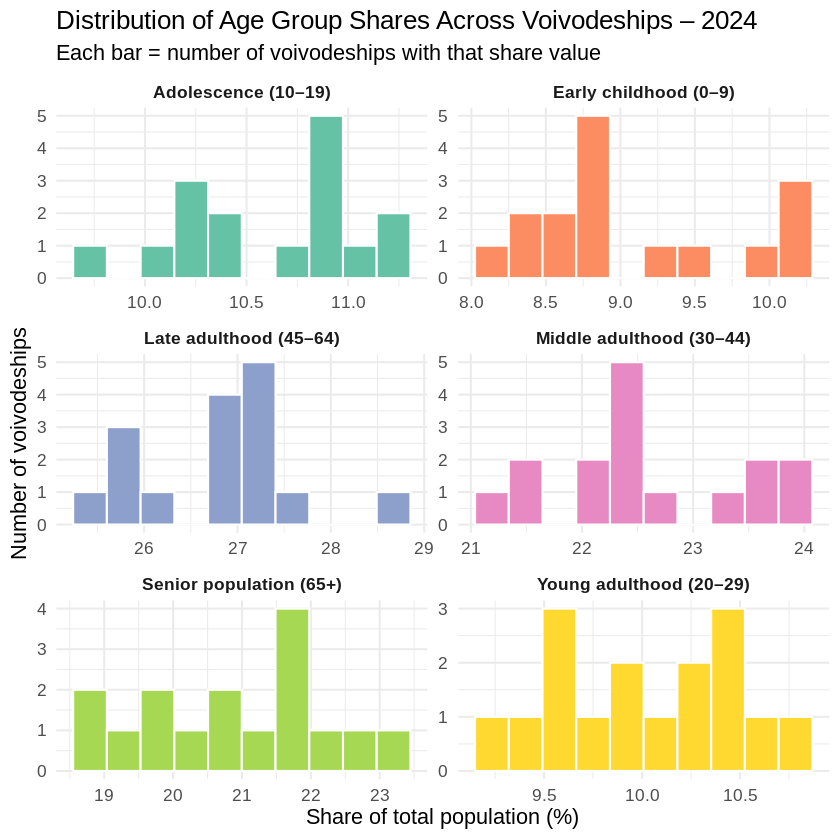

In [21]:
hist_year <- 2024

h <- age_shares %>%
  filter(year == hist_year) %>%
  ggplot(aes(x = share * 100, fill = age_category_label)) +
  geom_histogram(bins = 10, color = "white", show.legend = FALSE) +
  facet_wrap(~ age_category_label, scales = "free", ncol = 2) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title    = paste("Distribution of Age Group Shares Across Voivodeships –", hist_year),
    subtitle = "Each bar = number of voivodeships with that share value",
    x        = "Share of total population (%)",
    y        = "Number of voivodeships"
  ) +
  theme_minimal(base_size = 13) +
  theme(strip.text = element_text(face = "bold"))

ggsave("histogram.png", plot = h, width = 12, height = 8, dpi = 300)
h

The distributions show that some age groups vary more across regions than others. The senior population share has a relatively wide spread, which supports the idea that ageing is not equally advanced in every voivodeship.

### Age-group shares over time by voivodeship

The faceted line chart shows how each age group changed over time in every voivodeship. This graph is useful because it preserves the regional structure of the data while also showing long-term demographic trends.

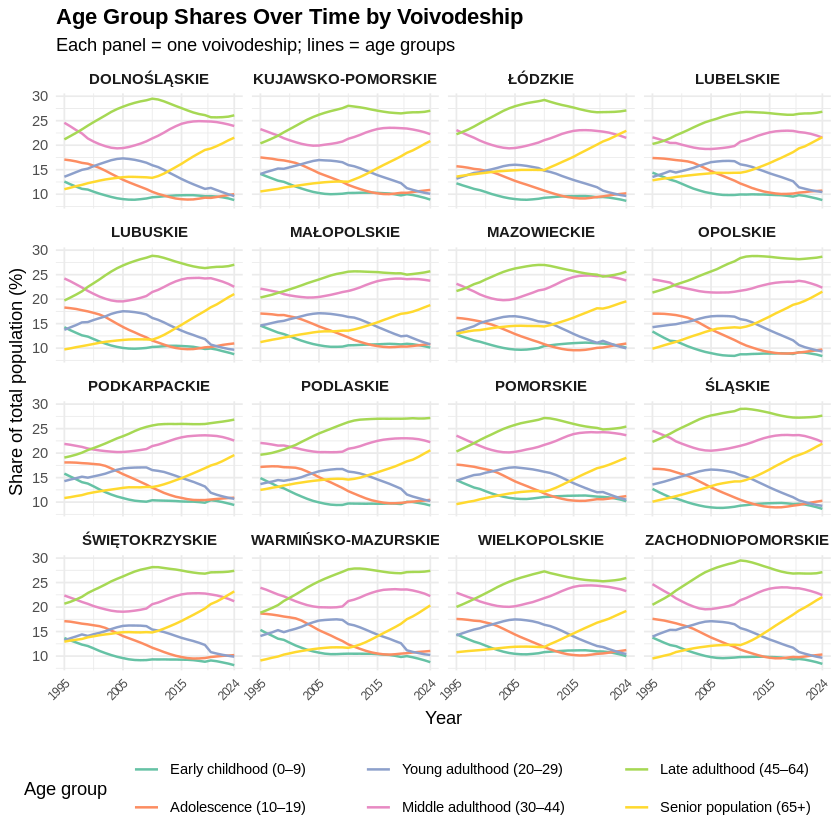

In [22]:
age_order <- c(
  "Early childhood (0–9)",
  "Adolescence (10–19)",
  "Young adulthood (20–29)",
  "Middle adulthood (30–44)",
  "Late adulthood (45–64)",
  "Senior population (65+)"
)

p <- age_shares %>%
  mutate(age_category_label = factor(age_category_label, levels = age_order)) %>%
  ggplot(aes(x = year, y = share * 100, color = age_category_label, group = age_category_label)) +
  geom_line(linewidth = 0.7) +
  facet_wrap(~ region, ncol = 4) +
  scale_color_brewer(palette = "Set2", name = "Age group") +
  scale_x_continuous(breaks = c(1995, 2005, 2015, 2024)) +
  labs(
    title    = "Age Group Shares Over Time by Voivodeship",
    subtitle = "Each panel = one voivodeship; lines = age groups",
    x        = "Year",
    y        = "Share of total population (%)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 9),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 7),
    plot.title       = element_text(face = "bold")
  ) +
  guides(color = guide_legend(nrow = 2))

ggsave("demographic_structure.png", plot = p, width = 12, height = 8, dpi = 300)
p

Across almost all regions, the senior population share rises strongly over time, while the shares of children and adolescents generally decline. This indicates a broad ageing process across Poland, although the speed and level of ageing differ by voivodeship.

### Focus on children, young adults, and seniors

This plot focuses on the three age groups most directly related to the question of whether regions are “younger” or “older”: early childhood, young adulthood, and senior population. Removing the other age groups makes the contrast between younger and older populations clearer.

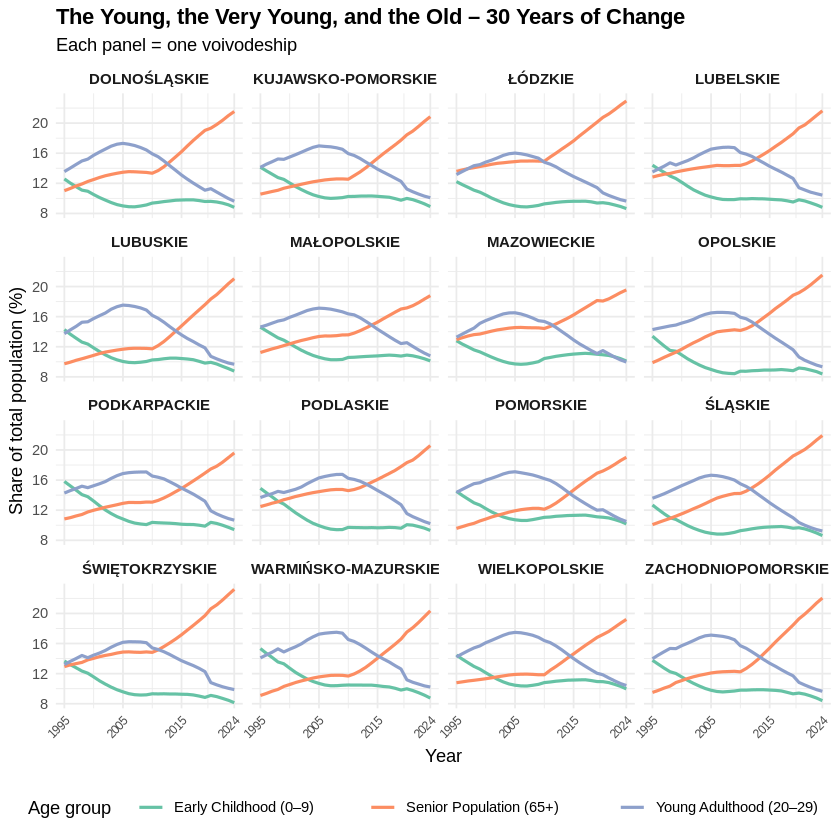

In [23]:
focus_categories <- c("early_childhood", "young_adulthood", "senior_population")

focus_labels <- c(
  early_childhood   = "Early Childhood (0–9)",
  young_adulthood   = "Young Adulthood (20–29)",
  senior_population = "Senior Population (65+)"
)

focus_colors <- c(
  "Early Childhood (0–9)"    = "#66C2A5",
  "Young Adulthood (20–29)"  = "#8DA0CB",
  "Senior Population (65+)"  = "#FC8D62"
)

p <- age_shares %>%
  filter(age_category %in% focus_categories) %>%
  mutate(age_category_label = focus_labels[age_category]) %>%
  ggplot(aes(x = year, y = share * 100, color = age_category_label, group = age_category_label)) +
  geom_line(linewidth = 0.9) +
  facet_wrap(~ region, ncol = 4) +
  scale_color_manual(values = focus_colors, name = "Age group") +
  scale_x_continuous(breaks = c(1995, 2005, 2015, 2024)) +
  labs(
    title    = "The Young, the Very Young, and the Old – 30 Years of Change",
    subtitle = "Each panel = one voivodeship",
    x        = "Year",
    y        = "Share of total population (%)"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    legend.position  = "bottom",
    strip.text       = element_text(face = "bold", size = 9),
    axis.text.x      = element_text(angle = 45, hjust = 1, size = 7),
    plot.title       = element_text(face = "bold")
  ) +
  guides(color = guide_legend(nrow = 1))

ggsave("demographic_structure_focus.png", plot = p, width = 12, height = 8, dpi = 300)
p

The senior population increases in every voivodeship, while early childhood generally decreases or remains low. Young adulthood rises until the mid-2000s in many regions and then declines. This pattern suggests a shift from a younger demographic structure toward an older one.

### Demographic structure in 1995 and 2024

The stacked bar chart compares the full age structure of each voivodeship in 1995 and 2024. Regions are sorted by their senior population share in 2024, so the most aged regions appear at the top.

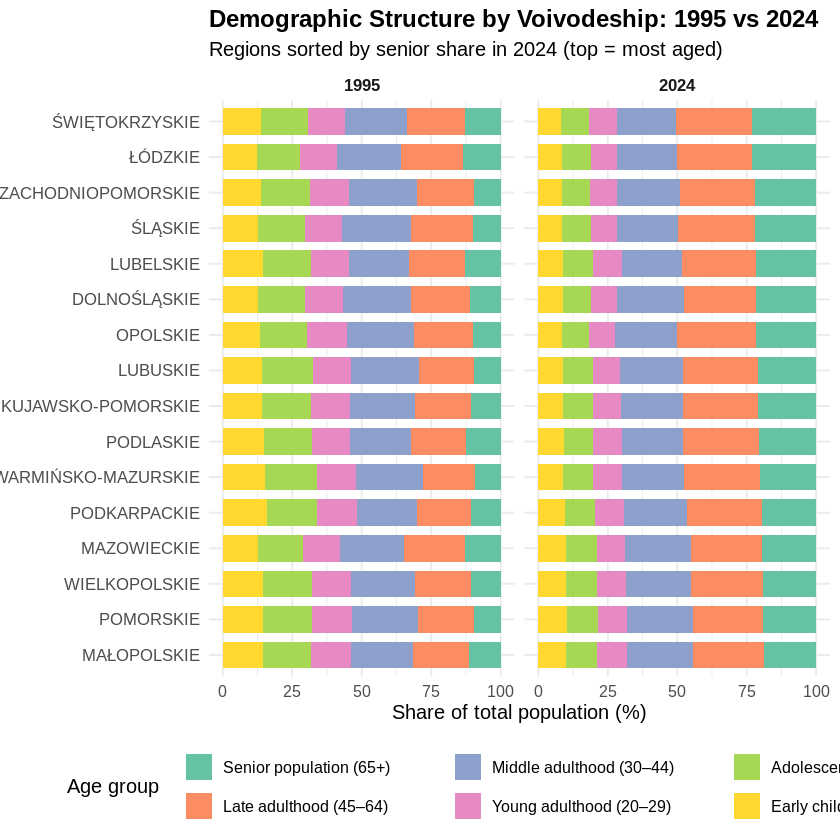

In [24]:
region_order_2024 <- age_shares %>%
  filter(year == 2024, age_category == "senior_population") %>%
  arrange(desc(share)) %>%
  distinct(region) %>%
  pull(region)

age_order <- c(
  "Senior population (65+)",
  "Late adulthood (45–64)",
  "Middle adulthood (30–44)",
  "Young adulthood (20–29)",
  "Adolescence (10–19)",
  "Early childhood (0–9)"
)

data_comparison <- age_shares %>%
  filter(year %in% c(1995, 2024)) %>%
  mutate(
    year               = factor(year),
    region             = factor(region, levels = rev(region_order_2024)),
    age_category_label = factor(age_category_label, levels = age_order)
  )

p <- ggplot(data_comparison, aes(x = region, y = share * 100, fill = age_category_label)) +
  geom_col(position = "stack", width = 0.75) +
  facet_wrap(~ year, ncol = 2) +
  scale_fill_brewer(palette = "Set2", name = "Age group") +
  coord_flip() +
  labs(
    title    = "Demographic Structure by Voivodeship: 1995 vs 2024",
    subtitle = "Regions sorted by senior share in 2024 (top = most aged)",
    x        = NULL,
    y        = "Share of total population (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    legend.position = "bottom",
    strip.text      = element_text(face = "bold", size = 10),
    axis.text.y     = element_text(size = 10),
    plot.title      = element_text(face = "bold")
  ) +
  guides(fill = guide_legend(nrow = 2))

ggsave("share_across_ages.png", plot = p, width = 12, height = 8, dpi = 300)
p

The comparison shows that the share of seniors increased substantially in every region. At the same time, younger age groups became smaller as a share of the population. This makes the ageing process visible not only in individual age groups, but in the entire demographic structure.

### Ranking voivodeships by senior population share in 2024

The lollipop chart ranks voivodeships by the share of people aged 65 or more in 2024. This graph directly answers which regions are the oldest according to the chosen definition of ageing.

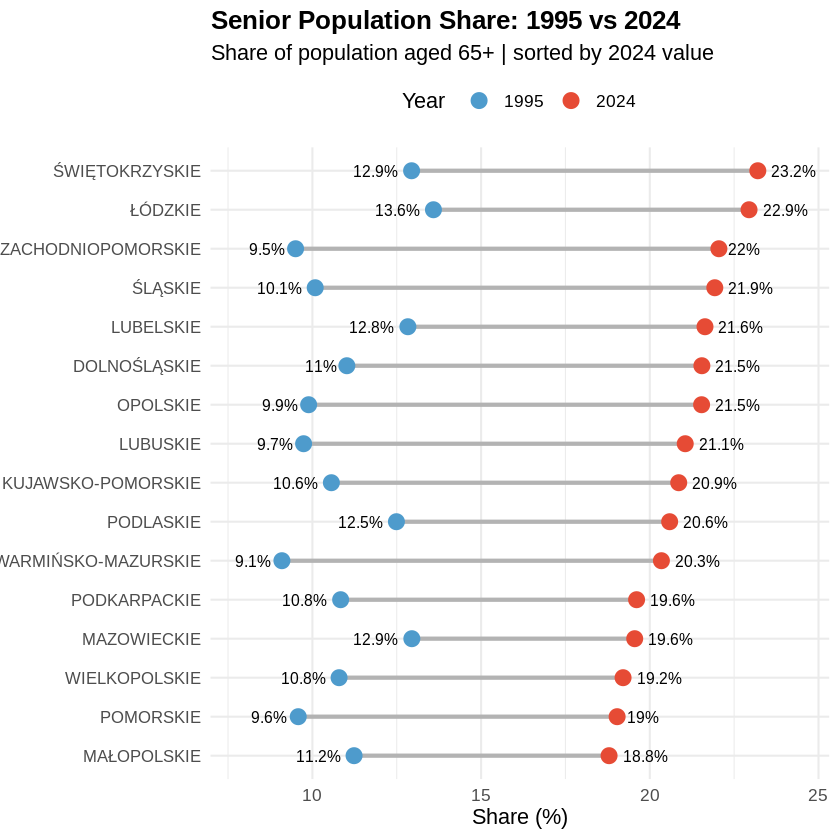

In [25]:
# Prepare: one row per region with both years side by side
seniors_compare <- age_shares %>%
  filter(year %in% c(1995, 2024), age_category == "senior_population") %>%
  select(region, year, share) %>%
  pivot_wider(names_from = year, values_from = share, names_prefix = "y") %>%
  mutate(region = fct_reorder(region, y2024))  # sort by 2024 value

p <- ggplot(seniors_compare) +
  geom_segment(aes(x = y1995 * 100, xend = y2024 * 100,
                   y = region,      yend = region),
               color = "grey70", linewidth = 1.2) +
  geom_point(aes(x = y1995 * 100, y = region, color = "1995"), size = 4) +
  geom_point(aes(x = y2024 * 100, y = region, color = "2024"), size = 4) +
  geom_text(aes(x = y2024 * 100, y = region,
                label = paste0(round(y2024 * 100, 1), "%")),
            hjust = -0.3, size = 3.3) +
  geom_text(aes(x = y1995 * 100, y = region,
                label = paste0(round(y1995 * 100, 1), "%")),
            hjust = 1.3, size = 3.3) +
  scale_color_manual(
    name   = "Year",
    values = c("1995" = "#4E9BCC", "2024" = "#E64B35")
  ) +
  scale_x_continuous(expand = expansion(mult = 0.15)) +
  labs(
    title    = "Senior Population Share: 1995 vs 2024",
    subtitle = "Share of population aged 65+ | sorted by 2024 value",
    x        = "Share (%)",
    y        = NULL
  ) +
  theme_minimal(base_size = 13) +
  theme(
    axis.text.y     = element_text(size = 10),
    legend.position = "top",
    plot.title      = element_text(face = "bold")
  )

ggsave("seniors_1995_vs_2024.png", plot = p, width = 12, height = 8, dpi = 300)
p

In 2024, the highest senior shares are observed in Świętokrzyskie, Łódzkie, and Zachodniopomorskie. The lowest senior shares are observed in Małopolskie, Pomorskie, and Wielkopolskie. Therefore, according to the senior-share measure, Świętokrzyskie and Łódzkie appear among the oldest regions, while Małopolskie and Pomorskie appear among the youngest.

## 5. Conclusion

The analysis shows that all Polish voivodeships experienced demographic ageing between 1995 and 2024. The share of the senior population increased in every region, while the shares of children and adolescents generally declined.

Regional differences are clearly visible in 2024. Świętokrzyskie, Łódzkie, and Zachodniopomorskie have the highest shares of people aged 65+, making them the oldest regions according to this measure. Małopolskie, Pomorskie, and Wielkopolskie have the lowest senior shares, making them relatively younger.

Overall, the project confirms that ageing is a nationwide trend, but its intensity differs between voivodeships.